# CEE6501 — Coding Assignment, Week 8

**Assigned:** 03/06/2026 (Week 8)  
**Due:** 03/22/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320766>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [598]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


In [599]:
# --- Version check ---
import numpy
import scipy
import matplotlib
import pandas
import plotly

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Imports

Run this cell once before starting the assignment.

In [600]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)


---

In this assignment, you will build on your Week 7 frame-analysis code to:

1. Implement a working **2D frame Direct Stiffness Method (DSM)** solver.
2. Extend your solver to handle **member moment releases** (Method A from lecture).
3. Extend your solver to handle **prescribed support displacements** (support settlements).

You will use the same baseline frame you solved by hand in **Week 7 written work** to verify correctness.

## Submission
- Name this notebook as: `LastName_A8_code.ipynb`
- All figures must render in the notebook.
- Include brief written responses after each problem.

## Requirements
- Your code must be readable and modular (functions, clear naming, comments).
- Verification matters: **match your Week 7 hand solution** for Problem 1.
- For Problems 2–3, include a short comparison + sanity check discussion.


## Notes
- Use consistent DOF ordering (as in lecture). For a 2D frame node, a common ordering is:
  - $[u_x,\; u_y,\; \theta_z]$ per node
- Clearly document your conventions at the top of your code.
- Use **plots** to help validate and interpret results.


---

## Problem 1 — Implement a 2D Frame Solver (Baseline)

Implement a **2D frame DSM solver** and use it to solve the **same frame** you solved by hand in the Week 7 written assignment.

You can use the code presented in Week 8 lecture as needed.

### Tasks
1. Implement your frame solver (assembly, partitioning, solution, reactions).
2. Solve the Week 7 frame and report:
   - Nodal displacements (including rotations)
   - Support reactions
   - Member end forces (local)
3. **Verify** your results by matching your Week 7 hand solution.
4. Plot the **undeformed and deformed** shape using your Week 7 plotting tools.

### What to include
- A clear statement of your DOF convention and sign convention.
- A small table or neatly formatted printout of key results.
- A plot showing undeformed + deformed geometry.


In [601]:
# Problem 1
# Add your code below (use as many cells as you need).
# Suggested structure:
# 1) Define nodes, elements, properties
# 2) Define loads and boundary conditions
# 3) Assemble global K and f
# 4) Solve for displacements
# 5) Recover reactions and member end forces
# 6) Plot undeformed + deformed

In [602]:
def restrained_dofs_1based(nodes_restrained, node_dofs_1based):
    """Return sorted list of restrained DOFs (1-based) from node restraints."""
    dof_restrained = []

    for node, restraints in nodes_restrained.items():
        ux_dof, uy_dof, rot_dof = node_dofs_1based(node)
        if "ux" in restraints:
            dof_restrained.append(ux_dof)
        if "uy" in restraints:
            dof_restrained.append(uy_dof)
        if "rot" in restraints:
            dof_restrained.append(rot_dof)

    return sorted(dof_restrained)

In [603]:
def FEF_calcu(elements_loaded, elements, nodes):
    """
    Convert element loads into accumulated nodal loads using equivalent nodal load formulas.

    Parameters
    ----------
    elements_loaded : dict
        Element load table, for example:
        {
            1: ("p", Fx, Fy, M),
            2: ("d", Fx, Fy, M)
        }

        load_type:
            "p" : concentrated load applied at the element midpoint
            "d" : uniformly distributed load over the full element

        Fx, Fy, M are all given in the element local coordinate system.

        For "p":
            Fx, Fy, M are concentrated values.

        For "d":
            Fx, Fy, M are distributed intensities per unit length.
    Returns
    -------
    FEF_loaded : dict
        Accumulated nodal loads in the global coordinate system:
        {
            node_id: (Fx, Fy, M)
        }
    """
    FEF_loaded = {}

    if not elements_loaded:
        return FEF_loaded

    for e_id, (load_type, Fx, Fy, M) in elements_loaded.items():
        i, j, E, A, I = elements[e_id]

        xi, yi = nodes[i]
        xj, yj = nodes[j]

        dx = xj - xi
        dy = yj - yi
        L = (dx**2 + dy**2) ** 0.5

        c = dx / L
        s = dy / L

        T = np.array([
            [ c,  s, 0.0, 0.0, 0.0, 0.0],
            [-s,  c, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0,  c,  s, 0.0],
            [0.0, 0.0, 0.0, -s,  c, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
        ], dtype=float)

        # Equivalent nodal loads in local coordinates
        if load_type == "p":
            f_local = np.array([
                Fx / 2.0,
                Fy / 2.0 - 3.0 * M / (2.0 * L),
                Fy * L / 8.0 - M / 4.0,
                Fx / 2.0,
                Fy / 2.0 + 3.0 * M / (2.0 * L),
                -Fy * L / 8.0 - M / 4.0
            ], dtype=float)

        elif load_type == "d":
            f_local = np.array([
                Fx * L / 2.0,
                Fy * L / 2.0 - M,
                Fy * L**2 / 12.0,
                Fx * L / 2.0,
                Fy * L / 2.0 + M,
                -Fy * L**2 / 12.0
            ], dtype=float)

        else:
            raise ValueError('load_type must be "p" or "d".')

        # Transform local equivalent nodal loads to global coordinates
        f_global = T.T @ f_local

        Fx_i, Fy_i, M_i, Fx_j, Fy_j, M_j = f_global

        if i not in FEF_loaded:
            FEF_loaded[i] = (0.0, 0.0, 0.0)
        if j not in FEF_loaded:
            FEF_loaded[j] = (0.0, 0.0, 0.0)

        Fx0, Fy0, M0 = FEF_loaded[i]
        FEF_loaded[i] = (Fx0 + Fx_i, Fy0 + Fy_i, M0 + M_i)

        Fx0, Fy0, M0 = FEF_loaded[j]
        FEF_loaded[j] = (Fx0 + Fx_j, Fy0 + Fy_j, M0 + M_j)

    return FEF_loaded

In [604]:
def loaded_dofs_1based(nodes_loaded, FEF_loaded, node_dofs_1based):
    """Return DOF→load mapping (1-based) from node loads and FEF-converted nodal loads."""
    dof_loaded = {}

    if nodes_loaded:
        for node, (Fx, Fy, M) in nodes_loaded.items():
            ux_dof, uy_dof, rot_dof = node_dofs_1based(node)
            if Fx != 0.0:
                dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
            if Fy != 0.0:
                dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy
            if M != 0.0:
                dof_loaded[rot_dof] = dof_loaded.get(rot_dof, 0.0) + M

    if FEF_loaded:
        for node, (Fx, Fy, M) in FEF_loaded.items():
            ux_dof, uy_dof, rot_dof = node_dofs_1based(node)
            if Fx != 0.0:
                dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
            if Fy != 0.0:
                dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy
            if M != 0.0:
                dof_loaded[rot_dof] = dof_loaded.get(rot_dof, 0.0) + M

    return dof_loaded

In [605]:
def node_dofs_1based(node_id):
    """Return engineering DOF numbers (1-based): [ux_dof, uy_dof, rot_dof]."""
    return [3 * node_id - 2, 3 * node_id - 1, 3 * node_id]

In [606]:
def element_csL(xy_i, xy_j):
    xy_i = np.asarray(xy_i, dtype=float)
    xy_j = np.asarray(xy_j, dtype=float)

    dx = xy_j[0] - xy_i[0]
    dy = xy_j[1] - xy_i[1]
    L = float(np.hypot(dx, dy))

    c = dx / L
    s = dy / L
    return float(c), float(s), float(L)


In [607]:
def build_elements_csl(elements, nodes):
    """Return dict mapping element_id -> (c, s, L)."""
    elements_csl = {}

    for e_id, (i, j, E_e, A_e, I_e) in elements.items():
        c, s, L = element_csL(nodes[i], nodes[j])
        elements_csl[e_id] = (c, s, L)

    return elements_csl

In [608]:
def initialize_global_stiffness(nodes):
    """Return zero-initialized global stiffness matrix."""
    ndof_total = 3 * len(nodes)
    return np.zeros((ndof_total, ndof_total), dtype=float)

In [609]:
def frame_element_kg(E, A, I, c, s, L):
    """Return 6x6 global stiffness matrix for a 2D frame element."""

    kl = (E * I) / L ** 3 * np.array([
        [A * L**2 / I, 0, 0, -A * L**2 / I, 0, 0],
        [0, 12, 6 * L, 0, -12, 6 * L],
        [0, 6 * L, 4 * L**2, 0, -6 * L, 2 * L**2],
        [-A * L**2 / I, 0, 0, A * L**2 / I, 0, 0],
        [0, -12, -6 * L, 0, 12, -6 * L],
        [0, 6 * L, 2 * L**2, 0, -6 * L, 4 * L**2]
    ], dtype=float)

    T = np.array([
            [ c,  s, 0.0, 0.0, 0.0, 0.0],
            [-s,  c, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0,  c,  s, 0.0],
            [0.0, 0.0, 0.0, -s,  c, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
        ], dtype=float)


    kg = T.T @ kl @ T

    return kg

In [610]:
def element_dof_map_1based(i_node, j_node):
    """Return the 6 global DOF indices (1-based) for element (i, j).

    Order matches the 6x6 element stiffness matrix:
    [u_ix, u_iy, theta_i, u_jx, u_jy, theta_j]
    """
    # Engineering DOF numbers (1-based)
    dofs_i_1 = [3 * i_node - 2, 3 * i_node - 1, 3 * i_node]
    dofs_j_1 = [3 * j_node - 2, 3 * j_node - 1, 3 * j_node]
    dofs_1based = dofs_i_1 + dofs_j_1
    return dofs_1based

In [611]:
def assemble_global_stiffness(elements, nodes, elements_csl, print_toggle):
    """Assemble and return the global stiffness matrix K (dense) for a 2D frame."""

    K = initialize_global_stiffness(nodes)

    for e_id, (i, j, E_e, A_e, I_e) in elements.items():
        c, s, L = elements_csl[e_id]
        ke = frame_element_kg(E_e, A_e, I_e, c, s, L)
        
        dof_map = element_dof_map_1based(i, j)

        # Scatter-add ke into K. Must be 0-based indexing, hence -1
        for a in range(6):
            A = dof_map[a] - 1
            for b in range(6):
                B = dof_map[b] - 1
                K[A, B] += ke[a, b]

        # Optional: show progress while learning/debugging
        if print_toggle:
            print_matrix_scaled(ke)
            print(f"Assembled element {e_id}: nodes ({i},{j}) -> DOFs {dof_map}")
            print_matrix_scaled(K)
            print("-" * 70)

    return K

In [612]:
def assemble_global_force_vector(nodes, dof_loaded_1based):
    """Return global force vector assembled from 1-based DOF loads."""
    ndof_total = 3 * len(nodes)
    f_global = np.zeros(ndof_total, dtype=float)

    for dof_1based, value in dof_loaded_1based.items():
        f_global[dof_1based - 1] = value  # convert to 0-based index

    return f_global

In [613]:
def partition_system(K, f, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(d - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    return K_ff, K_fr, K_rf, K_rr, f_f, f_r, free_dofs, restrained_dofs

In [614]:
def solve_free_displacements(K_ff, K_fr, f_f, u_r=None):
    if u_r is None:
        u_r = np.zeros(K_fr.shape[1])

    rhs = f_f - K_fr @ u_r
    u_f = np.linalg.solve(K_ff, rhs)

    return u_f

In [615]:
def solve_support_forces(K_rf, K_rr, u_f, f_r=None, u_r=None):
    if u_r is None:
        u_r = np.zeros(K_rr.shape[0])

    if f_r is None:
        f_r = np.zeros(K_rr.shape[0])

    F_r = K_rf @ u_f + K_rr @ u_r - f_r
    return F_r

In [616]:
def assemble_global_displacements(u_f, free_dofs, restrained_dofs, u_r=None):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global

In [617]:
def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global

In [618]:
def extract_element_displacements(u_global, i_node, j_node):
    """
    Extract the 4x1 element global displacement vector u_e.
    Order: [u_ix, u_iy, theta_i, u_jx, u_jy, theta_j]
    """
    dofs_1based = [3 * i_node - 2, 3 * i_node - 1, 3 * i_node,
                   3 * j_node - 2, 3 * j_node - 1, 3 * j_node]
    idx = [d - 1 for d in dofs_1based]  # convert to 0-based
    return u_global[idx]

In [619]:
def frame_transformation_matrix(c, s):
    return np.array([
        [c, s, 0, 0, 0, 0],
        [-s, c, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, c, s, 0],
        [0, 0, 0, -s, c, 0],
        [0, 0, 0, 0, 0, 1]
    ], dtype=float)

def compute_local_displacements(c, s, u_e):
    T = frame_transformation_matrix(c, s)
    return T @ u_e

In [620]:
def frame_local_stiffness(E, A, I, L):   
    return (E * I) / L ** 3 * np.array([
        [A * L**2 / I, 0, 0, -A * L**2 / I, 0, 0],
        [0, 12, 6 * L, 0, -12, 6 * L],
        [0, 6 * L, 4 * L**2, 0, -6 * L, 2 * L**2],
        [-A * L**2 / I, 0, 0, A * L**2 / I, 0, 0],
        [0, -12, -6 * L, 0, 12, -6 * L],
        [0, 6 * L, 2 * L**2, 0, -6 * L, 4 * L**2]
    ], dtype=float)

In [621]:
def compute_local_end_forces(E, A, I, L, u_local):
    k_local = frame_local_stiffness(E, A, I, L)
    return k_local @ u_local

In [622]:
def compute_axial_force_and_stress(E, A, L, u_local):
    # axial displacements are the local DOFs along the member axis
    u_i_axial = u_local[0]
    u_j_axial = u_local[3]

    N = (E * A / L) * (u_j_axial - u_i_axial)
    sigma = N / A
    return N, sigma

In [623]:
def local_to_global_forces(c, s, f_local):
    T = frame_transformation_matrix(c, s)
    return T.T @ f_local

In [624]:
def plot_frame_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[3*(i-1):3*(i-1)+3]
        uj = u_global[3*(j-1):3*(j-1)+3]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale*ui[0], xj + scale*uj[0]],
            [yi + scale*ui[1], yj + scale*uj[1]],
            "r-", lw=2
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()

In [625]:
def recover_element_results(elements, elements_csl, u_global):
    results = {}

    for e_id, (i, j, E_e, A_e, I_e) in elements.items():
        c, s, L = elements_csl[e_id]

        u_e = extract_element_displacements(u_global, i, j)
        u_local = compute_local_displacements(c, s, u_e)
        f_local = compute_local_end_forces(E_e, A_e, I_e, L, u_local)
        N, sigma = compute_axial_force_and_stress(E_e, A_e, L, u_local)

        results[e_id] = {
            "u_e": u_e,
            "u_local": u_local,
            "f_local": f_local,
            "N": N,          # kN
            "sigma": sigma,  # GPa
        }

    return results

In [626]:
def build_element_results_dataframe(elements, elements_csl, results):
    """Return pandas DataFrame of element-level results."""
    rows = []

    for e_id in sorted(elements.keys()):
        i, j, _, _, _ = elements[e_id]
        _, _, L = elements_csl[e_id]
        r = results[e_id]

        row = {
            "ele": e_id,
            "i": i,
            "j": j,
            "L (mm)": round(L, 1),
            "N (kN)": round(r["N"], 1),
            "sigma (MPa)": round(r["sigma"] * 1000, 1),
        }

        # global displacements u_e
        row.update({f"u_{k+1} (mm)": round(r["u_e"][k], 1) for k in range(6)})
        # local displacements u'
        row.update({f"u_{k+1}' (mm)": round(r["u_local"][k], 1) for k in range(6)})
        # local end forces f'
        row.update({f"f_{k+1}' (kN)": round(r["f_local"][k], 1) for k in range(6)})

        rows.append(row)

    return pd.DataFrame(rows)

In [627]:
def display_compact(df):
    return (
        df.style
        .format({
            col: "{:.1f}"
            for col in df.columns
            if any(key in col for key in ["(mm)", "(kN)", "(MPa)", "L"])
        })
        .set_properties(**{
            "font-size": "9pt",
            "padding": "2px",
            "white-space": "nowrap",
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-size", "9pt")]},
        ])
    )

In [628]:
def print_matrix_scaled(K, scale=1, decimals=2, col_width=7):
    """
    Print K/scale row-by-row, compact, with DOF labels.
    """
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:2d} | {row_str}")

In [629]:
def build_global_load_vector(n_dof, dof_loaded_1based):
    """dof_loaded_1based: {dof(1-based): value}  ->  F (0-based numpy vector)"""
    F = np.zeros(n_dof, dtype=float)
    for dof1, val in dof_loaded_1based.items():
        F[dof1 - 1] += val
    return F

In [630]:
def build_reaction_df(nodes_restrained, node_dofs_1based,
                      K_global, u_global, dof_loaded_1based,
                      decimals=1):
    """
    Return a DataFrame with support reactions at restrained nodes.
    Units: same as your loads (e.g., kN).
    """
    n_dof = K_global.shape[0]
    F = build_global_load_vector(n_dof, dof_loaded_1based)

    R = K_global @ u_global - F

    rows = []
    for node in sorted(nodes_restrained.keys()):
        ux, uy, rot = node_dofs_1based(node)

        Rx = R[ux - 1]
        Ry = R[uy - 1]
        M = R[rot - 1]

        rows.append({
            "node": node,
            "Rx (kN)": round(Rx, decimals),
            "Ry (kN)": round(Ry, decimals),
            "M (kN·m)": round(M, decimals)
        })

    return pd.DataFrame(rows)

In [631]:
def build_node_displacement_df(nodes, node_dofs_1based, u_global):
    """
    nodes: {node_id: (x,y)}
    node_dofs_1based(node) -> (ux_dof, uy_dof)  1-based
    u_global: full displacement vector
    """
    rows = []
    for n in sorted(nodes.keys()):
        coord = nodes[n]
        dofs = node_dofs_1based(n)

        ux = float(u_global[dofs[0]-1])
        uy = float(u_global[dofs[1]-1])
        rot = float(u_global[dofs[2]-1])

        umag = float(np.sqrt(ux**2 + uy**2))

        row = {"node": n, "x": coord[0], "y": coord[1], "ux (mm)": ux, "uy (mm)": uy, "rot (rad)": rot, "|u| (mm)": umag}

        rows.append(row)

    df = pd.DataFrame(rows)

    for c in df.columns:
        df[c] = df[c].astype(float).round(1)

    return df

In [632]:
def build_max_displacement_summary(df_disp):
    """
    Extract the maximum displacement (modulus length) and the positions of the maximum absolute values for each component from the node displacement table.
    """
    cols = df_disp.columns

    i_mag = df_disp["|u| (mm)"].astype(float).idxmax()
    r_mag = df_disp.loc[i_mag]

    summary_rows = [{
        "metric": "max |u|",
        "node": int(r_mag["node"]),
        "value (mm)": float(r_mag["|u| (mm)"]),
        "ux (mm)": float(r_mag["ux (mm)"]),
        "uy (mm)": float(r_mag["uy (mm)"]),
        "rot (rad)": float(r_mag["rot (rad)"])
    }]
    

    i_theta = df_disp["rot (rad)"].astype(float).abs().idxmax()
    r_theta = df_disp.loc[i_theta]
    summary_rows.append({
        "metric": "max |rot|",
        "node": int(r_theta["node"]),
        "value (mm)": None,
        "ux (mm)": float(r_theta["ux (mm)"]),
        "uy (mm)": float(r_theta["uy (mm)"]),
        "rot (rad)": float(r_theta["rot (rad)"]),
    })

    return pd.DataFrame(summary_rows)

In [633]:
# Node coordinates (global)
nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10000.0),
    3: (8000.0, 10000.0)
}

# Material and section properties
E = 200.0   # GPa
A = 4740.0    # mm^2
I = 22.2e6    # mm^4

# Element connectivity and properties
# Format: element_id : (start_node, end_node, E, A)
elements = {
    1: (1, 2, E, A, I),
    2: (2, 3, E, A, I)
}

elements_csl = build_elements_csl(elements, nodes)

print (elements)
print(elements_csl)

{1: (1, 2, 200.0, 4740.0, 22200000.0), 2: (2, 3, 200.0, 4740.0, 22200000.0)}
{1: (0.0, 1.0, 10000.0), 2: (1.0, 0.0, 8000.0)}


In [634]:
# Node-level description of restraints
# Values indicate which DOFs are fixed at each node
nodes_restrained = {
    1: ["ux", "uy", "rot"],   # fix
    3: ["ux", "uy"]          # pin
}

# Node-level applied loads (Fx, Fy, M)
nodes_loaded = None

# Element-level applied loads (type, Fx, Fy, M)
elements_loaded = {
    1: ("d", 0.0, -0.024, 0.0),  # element 1: local y-direction uniform load
    2: ("p", 0.0, -75.0, 0.0)   # element 2: midpoint concentrated load
}

FEF_loaded =  FEF_calcu(elements_loaded, elements, nodes)

dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_loaded_1based = loaded_dofs_1based(nodes_loaded, FEF_loaded, node_dofs_1based)

print(nodes_restrained)
print(nodes_loaded)

{1: ['ux', 'uy', 'rot'], 3: ['ux', 'uy']}
None


In [635]:
print_toggle = 0
K_global = assemble_global_stiffness(elements, nodes, elements_csl, print_toggle)
f_global = assemble_global_force_vector(nodes, dof_loaded_1based)

(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    free_dofs,
    restrained_dofs,
) = partition_system(K_global, f_global, dof_restrained_1based)

u_f = solve_free_displacements(K_ff, K_fr, f_f)
F_r = solve_support_forces(K_rf, K_rr, u_f, f_r)
u_global = assemble_global_displacements(u_f, free_dofs, restrained_dofs)
f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)

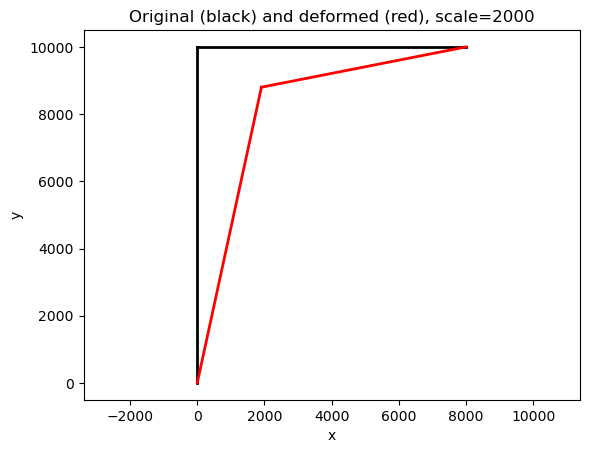

In [636]:
plot_frame_deformation(nodes, elements, u_global, scale=2000)

### Frame Setiup

### Response (Problem 1)

Compare your numerical solution to the **hand solution from the Week 7 written assignment**.

Address the following points:

- **Verification:**  
  Confirm whether your computed results match your hand calculations.  
  Identify which quantities you compared (for example: key displacements, reactions, or member end forces).

- **Key results:**  
  Summarize the most important outcomes from your analysis, including representative:
  - **nodal displacements**
  - **support reactions**
  - **member end forces**

- **Reasonableness check:**  
  Briefly explain why the results make sense from a **structural mechanics perspective** (for example: expected deformation direction, magnitude of reactions, or moment distribution).


---

---

## Problem 2 — Member Moment Release (Method A)

Modify your solver from Problem 1 to handle **member releases** implemented as **joints** using **Method A** from lecture.

You can use the code presented in Week 8 lecture as needed.

Use the same baseline structure from Problem 1, but introduce:

- A **moment release** at the **top-left node** (as specified in lecture/discussion).

### Tasks
1. Implement Method A (joint-based release modeling).
2. Solve the modified structure.
3. Report:
   - Updated nodal displacements
   - Updated reactions
   - Updated member end forces
4. Plot undeformed + deformed geometry.
5. Compare Problem 1 vs Problem 2 results.

In [637]:
# Problem 2
# Extend your solver to support a moment release using Method A.
# Add your code below (use as many cells as you need).


### Response (Problem 2)

Compare the results from **Problem 2** (with the moment release) to those from **Problem 1**.

Address the following points:

- **Observed changes:**  
  Identify the most significant differences in **nodal displacements, reactions, and/or member end moments**.

- **Structural interpretation:**  
  Explain **how and why the moment release changes the structural behavior**, including:
  - the **stiffness and load path** of the frame
  - the **rotations and internal moments near the released joint**

- **Reasonableness check:**  
  Briefly explain whether the results make sense physically.

- **Verification checks:**  
  Mention at least one check you used to validate the results (for example:
  - equilibrium of forces and moments,
  - reduced moment transfer at the released joint,
  - increased rotation at the released connection).

---

---

## Problem 3 — Support Settlement (Prescribed Support Displacements)

Modify your solver from Problem 1 to handle **prescribed support displacements** (support settlements), as described in lecture.

Use the same baseline structure from Problem 1, but impose the following support movement at the **top-right pin support**:

- $10\,\text{mm}$ **downward**
- $5\,\text{mm}$ **to the right**

*(Be careful with units: convert mm → m before solving.)*

### Tasks
1. Implement the partitioned-system method for prescribed displacements.
2. Solve the modified structure.
3. Report updated:
   - Nodal displacements
   - Reactions
   - Member end forces
4. Plot undeformed + deformed geometry.
5. Compare Problem 1 vs Problem 3 results.

In [638]:
# Problem 3
# Extend your solver to support prescribed displacements (support settlement).
# Add your code below (use as many cells as you need).


### Response (Problem 3)

Compare the results from **Problem 3** (with prescribed support displacements) to those from **Problem 1**.

Address the following points:

- **Observed changes:**  
  Summarize the most significant differences in **nodal displacements, support reactions, and/or member end forces**.

- **Structural interpretation:**  
  Explain **how prescribed support motion induces internal forces**, even when the external loading is unchanged.  
  Discuss how the imposed displacement alters compatibility conditions and generates additional forces in the structure.

- **Reasonableness check:**  
  Briefly explain whether the results make sense from a structural mechanics perspective (for example: induced reactions or internal forces due to constrained deformation).

- **Units and sign conventions:**  
  Confirm that the prescribed settlements were converted correctly (**mm → m**) and that your **sign conventions for displacements and forces** were applied consistently.

---

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE